# Module 1: Decision Tree Classifier (§2.1)

**CART (Classification and Regression Trees) — from scratch**

This notebook implements and analyzes a **binary Decision Tree** for classification
using the CART methodology. We use the **All dataset**
dataset to demonstrate training, prediction, and interpretation.

**Key concepts covered:**
- Gini impurity & Entropy (§2.1.2 DT.2)
- Exhaustive split search (§2.1.2 DT.3)
- Stopping criteria (§2.1.2 DT.4)
- Feature importances (§2.1.2 DT.6)
- sklearn baseline comparison (§2.1.3)

In [1]:
# === Imports and Setup ===
# ruff: noqa: E402
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.trees.decision_tree import DecisionTree
from src.utils.preprocessing import load_adult_income_data ,load_covertype_data, load_mnist_data, train_test_split, standardize
from src.trees.boosting.adaboost import DecisionStump
from src.metrics.evaluation import accuracy_calculation, f1_score, auc_roc
from sklearn.tree import DecisionTreeClassifier
RANDOM_STATE = 42
%matplotlib inline

---
## 1. Load and Explore All datset

In [2]:
from src.utils.preprocessing import load_breast_cancer # noqa: E402

data = load_breast_cancer()
X, y = data.data, data.target
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Classes: {np.unique(y)} ({len(np.unique(y))} classes)")
print(f"Class distribution: {np.bincount(y)}")

X_adult, y_adult, df_adult = load_adult_income_data()
Z = X_adult
t = y_adult.str.strip().map({
    '<=50K': 0,
    '>50K': 1
}).values
print(f"Samples: {Z.shape[0]}, Features: {Z.shape[1]}")
print(f"Classes: {np.unique(t)} ({len(np.unique(t))} classes)")
print(f"Class distribution: {np.bincount(t)}")

A, b, df_cover = load_covertype_data()
# y DataFrame olduğu üçün sütunu götürürük
b = b.values
print(f"Samples: {A.shape[0]}, Features: {A.shape[1]}")
print(f"Classes: {np.unique(b)} ({len(np.unique(b))} classes)")
print(f"Class distribution: {np.bincount(b)}")

M, n, df_mnist = load_mnist_data()
n = n.values 
print(f"Samples: {M.shape[0]}, Features: {M.shape[1]}")
print(f"Classes: {np.unique(n)} ({len(np.unique(n))} classes)")
print(f"Class distribution: {np.bincount(n)}")

Samples: 569, Features: 30
Classes: [0 1] (2 classes)
Class distribution: [212 357]
Loaded from Parquet: /Users/student/Desktop/ML_PROJECT-main/data/adult_income.parquet
Samples: 48842, Features: 6
Classes: [0 1] (2 classes)
Class distribution: [37155 11687]
Loaded from Parquet: /Users/student/Desktop/ML_PROJECT-main/data/covertype.parquet
Samples: 581012, Features: 10
Classes: [1 2 3 4 5 6 7] (7 classes)
Class distribution: [     0 211840 283301  35754   2747   9493  17367  20510]
Loaded from Parquet: /Users/student/Desktop/ML_PROJECT-main/data/mnist.parquet
Samples: 70000, Features: 784
Classes: [0 1 2 3 4 5 6 7 8 9] (10 classes)
Class distribution: [6903 7877 6990 7141 6824 6313 6876 7293 6825 6958]


## 2. Train-Test Split and Standardization

Standardize features to zero mean, unit variance (fit on train only).

In [3]:
Z = np.asarray(Z)
t = np.asarray(t)

A = np.asarray(A)
b = np.asarray(b)

M = np.asarray(M)
n = np.asarray(n)
# Breast Cancer
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train_s, X_test_s = standardize(X_train, X_test)
print(f"Breast Cancer -> Train: {X_train_s.shape}, Test: {X_test_s.shape}")

# Adult Income
Z_train, Z_test, t_train, t_test = train_test_split(
    Z, t, test_size=0.2, random_state=RANDOM_STATE
)
Z_train_s, Z_test_s = standardize(Z_train, Z_test)
print(f"Adult Income -> Train: {Z_train_s.shape}, Test: {Z_test_s.shape}")

# Covertype
A_train, A_test, b_train, b_test = train_test_split(
    A, b, test_size=0.2, random_state=RANDOM_STATE
)
A_train_s, A_test_s = standardize(A_train, A_test)
print(f"Covertype -> Train: {A_train_s.shape}, Test: {A_test_s.shape}")

# MNIST
M_train, M_test, n_train, n_test = train_test_split(
    M, n, test_size=0.2, random_state=RANDOM_STATE
)
M_train_s, M_test_s = standardize(M_train, M_test)
print(f"MNIST -> Train: {M_train_s.shape}, Test: {M_test_s.shape}")

Breast Cancer -> Train: (455, 30), Test: (114, 30)
Adult Income -> Train: (39073, 6), Test: (9769, 6)
Covertype -> Train: (464809, 10), Test: (116203, 10)
MNIST -> Train: (56000, 784), Test: (14000, 784)


---
## 3. Train a Decision Tree from Scratch

### 3.1 Default tree (unpruned)

In [4]:
# Breast Cancer
dt_bc = DecisionTree(random_state=RANDOM_STATE)
dt_bc.fit(X_train_s, y_train)

pred_bc = dt_bc.predict(X_test_s)
proba_bc = dt_bc.predict_proba(X_test_s)

print("=== Breast Cancer ===")
print(f"Tree depth: {dt_bc.depth}")
print(f"Number of leaves: {dt_bc.n_leaves}")
print(f"Accuracy: {accuracy_calculation(y_test, pred_bc):.4f}")
print(f"Macro F1: {f1_score(y_test, pred_bc):.4f}")
print(f"AUC-ROC: {auc_roc(y_test, proba_bc):.4f}")

# Adult Income
dt_adult = DecisionTree(random_state=RANDOM_STATE)
dt_adult.fit(Z_train_s, t_train)

pred_adult = dt_adult.predict(Z_test_s)
proba_adult = dt_adult.predict_proba(Z_test_s)

print("\n=== Adult Income ===")
print(f"Tree depth: {dt_adult.depth}")
print(f"Number of leaves: {dt_adult.n_leaves}")
print(f"Accuracy: {accuracy_calculation(t_test, pred_adult):.4f}")
print(f"Macro F1: {f1_score(t_test, pred_adult):.4f}")
print(f"AUC-ROC: {auc_roc(t_test, proba_adult):.4f}")

# Covertype
dt_cover = DecisionTree(random_state=RANDOM_STATE)
dt_cover.fit(A_train_s, b_train)

pred_cover = dt_cover.predict(A_test_s)
proba_cover = dt_cover.predict_proba(A_test_s)

print("\n=== Covertype ===")
print(f"Tree depth: {dt_cover.depth}")
print(f"Number of leaves: {dt_cover.n_leaves}")
print(f"Accuracy: {accuracy_calculation(b_test, pred_cover):.4f}")
print(f"Macro F1: {f1_score(b_test, pred_cover):.4f}")
print(f"AUC-ROC: {auc_roc(b_test, proba_cover):.4f}")

# MNIST

dt_mnist = DecisionTree(random_state=RANDOM_STATE)
dt_mnist.fit(M_train_s, n_train)

pred_mnist = dt_mnist.predict(M_test_s)
proba_mnist = dt_mnist.predict_proba(M_test_s)

print("\n=== MNIST ===")
print(f"Tree depth: {dt_mnist.depth}")
print(f"Number of leaves: {dt_mnist.n_leaves}")
print(f"Accuracy: {accuracy_calculation(n_test, pred_mnist):.4f}")
print(f"Macro F1: {f1_score(n_test, pred_mnist):.4f}")
print(f"AUC-ROC: {auc_roc(n_test, proba_mnist):.4f}")

=== Breast Cancer ===
Tree depth: 7
Number of leaves: 15
Accuracy: 0.9561
Macro F1: 0.9539
AUC-ROC: 0.9468

=== Adult Income ===
Tree depth: 62
Number of leaves: 8024
Accuracy: 0.7783
Macro F1: 0.6981
AUC-ROC: 0.6997

=== Covertype ===
Tree depth: 39
Number of leaves: 31271
Accuracy: 0.9178
Macro F1: 0.8733
AUC-ROC: 0.9265

=== MNIST ===
Tree depth: 43
Number of leaves: 3732
Accuracy: 0.8749
Macro F1: 0.8734
AUC-ROC: 0.9298


### 3.2 Tree Structure Visualization

For shallow trees (depth ≤ 4), `__repr__` prints an indented text tree
showing split decisions, class distributions, and sample counts (§2.1.2 DT.7).

In [5]:
# Train a shallow tree for readability
# Breast Cancer
shallow_dt_bc = DecisionTree(max_depth=3, random_state=RANDOM_STATE)
shallow_dt_bc.fit(X_train_s, y_train)
print("=== Breast Cancer ===")
print(shallow_dt_bc)

# Adult Income
shallow_dt_adult = DecisionTree(max_depth=3, random_state=RANDOM_STATE)
shallow_dt_adult.fit(Z_train_s, t_train)
print("\n=== Adult Income ===")
print(shallow_dt_adult)

# Covertype
shallow_dt_cover = DecisionTree(max_depth=3, random_state=RANDOM_STATE)
shallow_dt_cover.fit(A_train_s, b_train)
print("\n=== Covertype ===")
print(shallow_dt_cover)

# MNIST
shallow_dt_mnist = DecisionTree(max_depth=3, random_state=RANDOM_STATE)
shallow_dt_mnist.fit(M_train_s, n_train)
print("\n=== MNIST ===")
print(shallow_dt_mnist)

=== Breast Cancer ===
DecisionTree(depth=3, n_leaves=7, criterion=gini)
feature_23 <= 0.0213, gini=0.4623, samples=455, value=[165.00, 290.00]
|   feature_27 <= 0.7095, gini=0.1437, samples=308, value=[24.00, 284.00]
|   |   feature_27 <= 0.2841, gini=0.0723, samples=293, value=[11.00, 282.00]
|   |   |   leaf: gini=0.0222, samples=267, value=[3.00, 264.00], probs=[0.01, 0.99]
|   |   |   leaf: gini=0.4260, samples=26, value=[8.00, 18.00], probs=[0.31, 0.69]
|   |   feature_21 <= -0.3804, gini=0.2311, samples=15, value=[13.00, 2.00]
|   |   |   leaf: gini=0.0000, samples=2, value=[0.00, 2.00], probs=[0.00, 1.00]
|   |   |   leaf: gini=0.0000, samples=13, value=[13.00, 0.00], probs=[1.00, 0.00]
|   feature_6 <= -0.2085, gini=0.0783, samples=147, value=[141.00, 6.00]
|   |   feature_1 <= 0.0558, gini=0.4688, samples=16, value=[10.00, 6.00]
|   |   |   leaf: gini=0.2449, samples=7, value=[1.00, 6.00], probs=[0.14, 0.86]
|   |   |   leaf: gini=0.0000, samples=9, value=[9.00, 0.00], probs=[

## 4. Gini vs Entropy — Criterion Comparison (§2.1.2 DT.2)

**Gini impurity:** $I_G(p) = 1 - \sum_{c=1}^C p_c^2$

**Entropy:** $I_E(p) = -\sum_{c=1}^C p_c \log_2(p_c + \epsilon)$

Both measure node impurity. Gini is faster; entropy produces slightly
more balanced trees. Let's compare:

In [6]:
# Breast Cancer
dt_gini_bc = DecisionTree(max_depth=5, criterion="gini", random_state=RANDOM_STATE)
dt_entropy_bc = DecisionTree(max_depth=5, criterion="entropy", random_state=RANDOM_STATE)
dt_gini_bc.fit(X_train_s, y_train)
dt_entropy_bc.fit(X_train_s, y_train)
acc_gini_bc = accuracy_calculation(y_test, dt_gini_bc.predict(X_test_s))
acc_entropy_bc = accuracy_calculation(y_test, dt_entropy_bc.predict(X_test_s))
print("=== Breast Cancer ===")
print(f"Gini    — depth={dt_gini_bc.depth}, leaves={dt_gini_bc.n_leaves}, acc={acc_gini_bc:.4f}")
print(f"Entropy — depth={dt_entropy_bc.depth}, leaves={dt_entropy_bc.n_leaves}, acc={acc_entropy_bc:.4f}")

# Adult Income
dt_gini_adult = DecisionTree(max_depth=5, criterion="gini", random_state=RANDOM_STATE)
dt_entropy_adult = DecisionTree(max_depth=5, criterion="entropy", random_state=RANDOM_STATE)
dt_gini_adult.fit(Z_train_s, t_train)
dt_entropy_adult.fit(Z_train_s, t_train)
acc_gini_adult = accuracy_calculation(t_test, dt_gini_adult.predict(Z_test_s))
acc_entropy_adult = accuracy_calculation(t_test, dt_entropy_adult.predict(Z_test_s))
print("\n=== Adult Income ===")
print(f"Gini    — depth={dt_gini_adult.depth}, leaves={dt_gini_adult.n_leaves}, acc={acc_gini_adult:.4f}")
print(f"Entropy — depth={dt_entropy_adult.depth}, leaves={dt_entropy_adult.n_leaves}, acc={acc_entropy_adult:.4f}")

# Covertype
dt_gini_cover = DecisionTree(max_depth=5, criterion="gini", random_state=RANDOM_STATE)
dt_entropy_cover = DecisionTree(max_depth=5, criterion="entropy", random_state=RANDOM_STATE)
dt_gini_cover.fit(A_train_s, b_train)
dt_entropy_cover.fit(A_train_s, b_train)
acc_gini_cover = accuracy_calculation(b_test, dt_gini_cover.predict(A_test_s))
acc_entropy_cover = accuracy_calculation(b_test, dt_entropy_cover.predict(A_test_s))
print("\n=== Covertype ===")
print(f"Gini    — depth={dt_gini_cover.depth}, leaves={dt_gini_cover.n_leaves}, acc={acc_gini_cover:.4f}")
print(f"Entropy — depth={dt_entropy_cover.depth}, leaves={dt_entropy_cover.n_leaves}, acc={acc_entropy_cover:.4f}")

# MNIST
dt_gini_mnist = DecisionTree(max_depth=5, criterion="gini", random_state=RANDOM_STATE)
dt_entropy_mnist = DecisionTree(max_depth=5, criterion="entropy", random_state=RANDOM_STATE)
dt_gini_mnist.fit(M_train_s, n_train)
dt_entropy_mnist.fit(M_train_s, n_train)
acc_gini_mnist = accuracy_calculation(n_test, dt_gini_mnist.predict(M_test_s))
acc_entropy_mnist = accuracy_calculation(n_test, dt_entropy_mnist.predict(M_test_s))
print("\n=== MNIST ===")
print(f"Gini    — depth={dt_gini_mnist.depth}, leaves={dt_gini_mnist.n_leaves}, acc={acc_gini_mnist:.4f}")
print(f"Entropy — depth={dt_entropy_mnist.depth}, leaves={dt_entropy_mnist.n_leaves}, acc={acc_entropy_mnist:.4f}")

=== Breast Cancer ===
Gini    — depth=5, leaves=12, acc=0.9474
Entropy — depth=5, leaves=13, acc=0.9474

=== Adult Income ===
Gini    — depth=5, leaves=27, acc=0.8323
Entropy — depth=5, leaves=25, acc=0.8213

=== Covertype ===
Gini    — depth=5, leaves=32, acc=0.6945
Entropy — depth=5, leaves=32, acc=0.6901

=== MNIST ===
Gini    — depth=5, leaves=32, acc=0.6753
Entropy — depth=5, leaves=32, acc=0.6854


## 5. Feature Importances (§2.1.2 DT.6)

The importance of feature $j$ is the normalized sum of impurity reductions
over all splits that use feature $j$:

$$\text{Importance}_j = \frac{\sum_{s: j_s = j} \Delta I_s \cdot N_s}{\sum_{k} \sum_{s: j_s = k} \Delta I_s \cdot N_s}$$

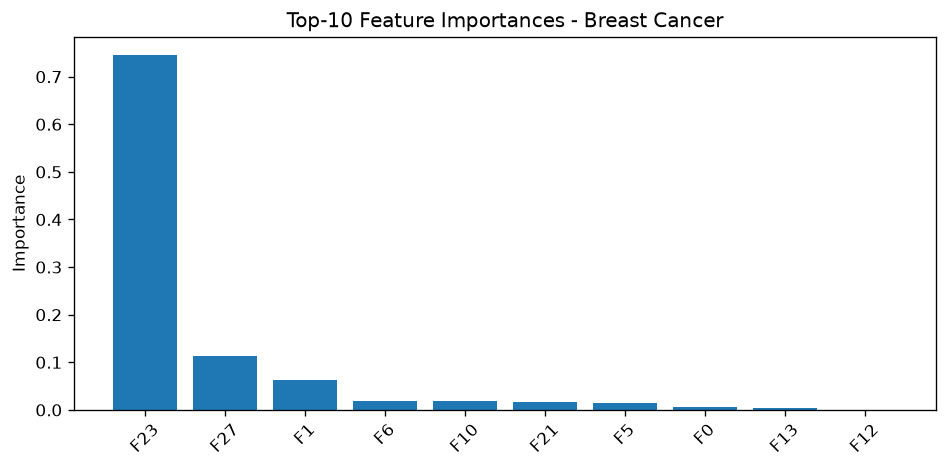

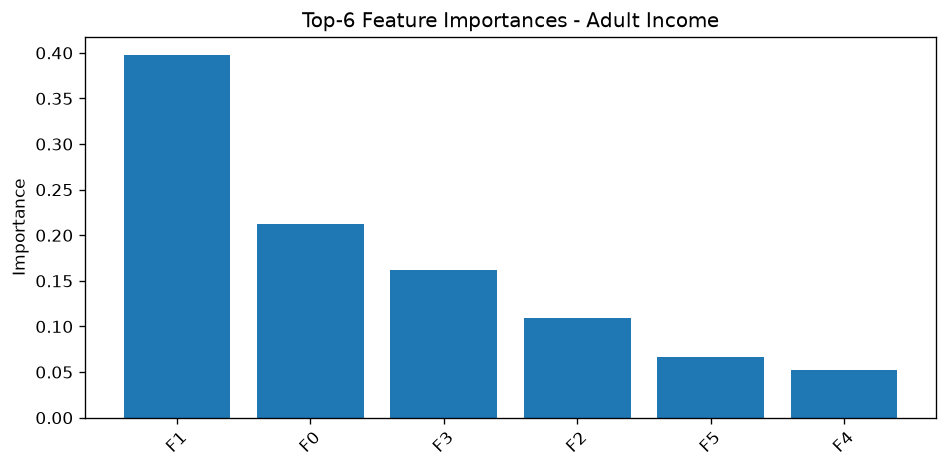

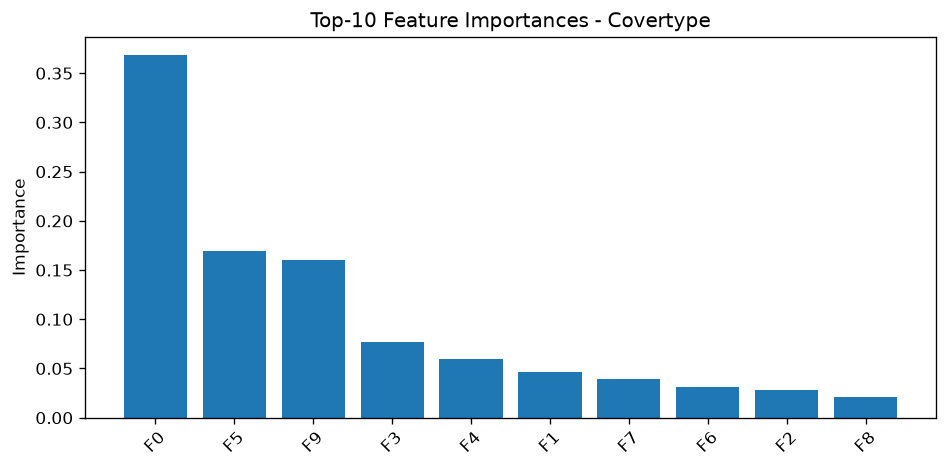

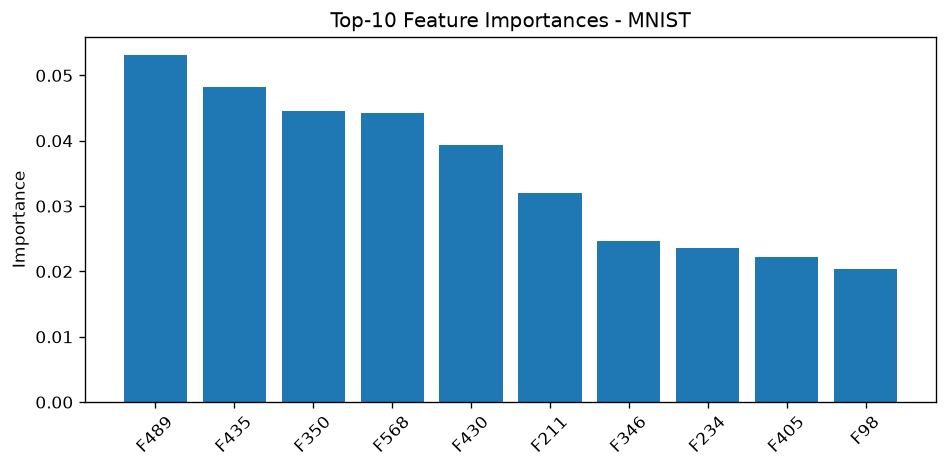

In [7]:
# Breast Cancer
fi = dt_bc.feature_importances()
top_k = 10
top_indices = np.argsort(fi)[::-1][:top_k]
plt.figure(figsize=(8, 4))
plt.bar(range(top_k), fi[top_indices])
plt.xticks(range(top_k), [f"F{i}" for i in top_indices], rotation=45)
plt.ylabel("Importance")
plt.title("Top-10 Feature Importances - Breast Cancer")
plt.tight_layout()
plt.savefig("../figures/feature_importance_breast_cancer.png", dpi=300, bbox_inches="tight")
plt.show()

# Adult Income
fi = dt_adult.feature_importances()
top_k = 6
top_indices = np.argsort(fi)[::-1][:top_k]
plt.figure(figsize=(8, 4))
plt.bar(range(top_k), fi[top_indices])
plt.xticks(range(top_k), [f"F{i}" for i in top_indices], rotation=45)
plt.ylabel("Importance")
plt.title("Top-6 Feature Importances - Adult Income")
plt.tight_layout()
plt.savefig("../figures/feature_importance_adult_income.png", dpi=300, bbox_inches="tight")
plt.show()

# Covertype
fi = dt_cover.feature_importances()
top_k = 10
top_indices = np.argsort(fi)[::-1][:top_k]
plt.figure(figsize=(8, 4))
plt.bar(range(top_k), fi[top_indices])
plt.xticks(range(top_k), [f"F{i}" for i in top_indices], rotation=45)
plt.ylabel("Importance")
plt.title("Top-10 Feature Importances - Covertype")
plt.tight_layout()
plt.savefig("../figures/feature_importance_covertype.png", dpi=300, bbox_inches="tight")
plt.show()

# MNIST
fi = dt_mnist.feature_importances()
top_k = 10
top_indices = np.argsort(fi)[::-1][:top_k]
plt.figure(figsize=(8, 4))
plt.bar(range(top_k), fi[top_indices])
plt.xticks(range(top_k), [f"F{i}" for i in top_indices], rotation=45)
plt.ylabel("Importance")
plt.title("Top-10 Feature Importances - MNIST")
plt.tight_layout()
plt.savefig("../figures/feature_importance_mnist.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

## 6. sklearn Baseline Comparison (§2.1.3)

Verify that our implementation matches `sklearn.tree.DecisionTreeClassifier`
within 2% tolerance.

In [8]:
# Breast Cancer
sk_dt_bc = DecisionTreeClassifier(random_state=RANDOM_STATE)
sk_dt_bc.fit(X_train_s, y_train)
sk_pred_bc = sk_dt_bc.predict(X_test_s)
sk_proba_bc = sk_dt_bc.predict_proba(X_test_s)
our_pred_bc = dt_bc.predict(X_test_s)
our_proba_bc = dt_bc.predict_proba(X_test_s)
our_acc_bc = accuracy_calculation(y_test, our_pred_bc)
sk_acc_bc = accuracy_calculation(y_test, sk_pred_bc)
diff_pct_bc = abs(our_acc_bc - sk_acc_bc) / max(sk_acc_bc, 1e-10) * 100
print("=== Breast Cancer ===")
print(f"Our Decision Tree: Acc={our_acc_bc:.4f}, F1={f1_score(y_test, our_pred_bc):.4f}, AUC={auc_roc(y_test, our_proba_bc):.4f}")
print(f"sklearn Tree:      Acc={sk_acc_bc:.4f}, F1={f1_score(y_test, sk_pred_bc):.4f}, AUC={auc_roc(y_test, sk_proba_bc):.4f}")
print(f"Difference: {diff_pct_bc:.2f}% ({'PASS' if diff_pct_bc <= 2 else 'FAIL'})")

# Adult Income
sk_dt_adult = DecisionTreeClassifier(random_state=RANDOM_STATE)
sk_dt_adult.fit(Z_train_s, t_train)
sk_pred_adult = sk_dt_adult.predict(Z_test_s)
sk_proba_adult = sk_dt_adult.predict_proba(Z_test_s)
our_pred_adult = dt_adult.predict(Z_test_s)
our_proba_adult = dt_adult.predict_proba(Z_test_s)
our_acc_adult = accuracy_calculation(t_test, our_pred_adult)
sk_acc_adult = accuracy_calculation(t_test, sk_pred_adult)
diff_pct_adult = abs(our_acc_adult - sk_acc_adult) / max(sk_acc_adult, 1e-10) * 100
print("\n=== Adult Income ===")
print(f"Our Decision Tree: Acc={our_acc_adult:.4f}, F1={f1_score(t_test, our_pred_adult):.4f}, AUC={auc_roc(t_test, our_proba_adult):.4f}")
print(f"sklearn Tree:      Acc={sk_acc_adult:.4f}, F1={f1_score(t_test, sk_pred_adult):.4f}, AUC={auc_roc(t_test, sk_proba_adult):.4f}")
print(f"Difference: {diff_pct_adult:.2f}% ({'PASS' if diff_pct_adult <= 2 else 'FAIL'})")

# Covertype
sk_dt_cover = DecisionTreeClassifier(random_state=RANDOM_STATE)
sk_dt_cover.fit(A_train_s, b_train)
sk_pred_cover = sk_dt_cover.predict(A_test_s)
sk_proba_cover = sk_dt_cover.predict_proba(A_test_s)
our_pred_cover = dt_cover.predict(A_test_s)
our_proba_cover = dt_cover.predict_proba(A_test_s)
our_acc_cover = accuracy_calculation(b_test, our_pred_cover)
sk_acc_cover = accuracy_calculation(b_test, sk_pred_cover)
diff_pct_cover = abs(our_acc_cover - sk_acc_cover) / max(sk_acc_cover, 1e-10) * 100
print("\n=== Covertype ===")
print(f"Our Decision Tree: Acc={our_acc_cover:.4f}, F1={f1_score(b_test, our_pred_cover, mean='macro'):.4f}, AUC={auc_roc(b_test, our_proba_cover):.4f}")
print(f"sklearn Tree:      Acc={sk_acc_cover:.4f}, F1={f1_score(b_test, sk_pred_cover, mean='macro'):.4f}, AUC={auc_roc(b_test, sk_proba_cover):.4f}")
print(f"Difference: {diff_pct_cover:.2f}% ({'PASS' if diff_pct_cover <= 2 else 'FAIL'})")

# MNIST
sk_dt_mnist = DecisionTreeClassifier(random_state=RANDOM_STATE)
sk_dt_mnist.fit(M_train_s, n_train)
sk_pred_mnist = sk_dt_mnist.predict(M_test_s)
sk_proba_mnist = sk_dt_mnist.predict_proba(M_test_s)
our_pred_mnist = dt_mnist.predict(M_test_s)
our_proba_mnist = dt_mnist.predict_proba(M_test_s)
our_acc_mnist = accuracy_calculation(n_test, our_pred_mnist)
sk_acc_mnist = accuracy_calculation(n_test, sk_pred_mnist)
diff_pct_mnist = abs(our_acc_mnist - sk_acc_mnist) / max(sk_acc_mnist, 1e-10) * 100
print("\n=== MNIST ===")
print(f"Our Decision Tree: Acc={our_acc_mnist:.4f}, F1={f1_score(n_test, our_pred_mnist, mean='macro'):.4f}, AUC={auc_roc(n_test, our_proba_mnist):.4f}")
print(f"sklearn Tree:      Acc={sk_acc_mnist:.4f}, F1={f1_score(n_test, sk_pred_mnist, mean='macro'):.4f}, AUC={auc_roc(n_test, sk_proba_mnist):.4f}")
print(f"Difference: {diff_pct_mnist:.2f}% ({'PASS' if diff_pct_mnist <= 2 else 'FAIL'})")

=== Breast Cancer ===
Our Decision Tree: Acc=0.9561, F1=0.9539, AUC=0.9468
sklearn Tree:      Acc=0.9386, F1=0.9364, AUC=0.9351
Difference: 1.87% (PASS)

=== Adult Income ===
Our Decision Tree: Acc=0.7783, F1=0.6981, AUC=0.6997
sklearn Tree:      Acc=0.7763, F1=0.6969, AUC=0.6996
Difference: 0.25% (PASS)

=== Covertype ===
Our Decision Tree: Acc=0.9178, F1=0.8733, AUC=0.9265
sklearn Tree:      Acc=0.9189, F1=0.8729, AUC=0.9258
Difference: 0.13% (PASS)

=== MNIST ===
Our Decision Tree: Acc=0.8749, F1=0.8734, AUC=0.9298
sklearn Tree:      Acc=0.8758, F1=0.8742, AUC=0.9302
Difference: 0.10% (PASS)


# 7 Depth vs Accuracy Tradeoff
Varying `max_depth` shows the bias-variance tradeoff:
- Shallow trees underfit (high bias)
- Deep trees overfit (high variance) 


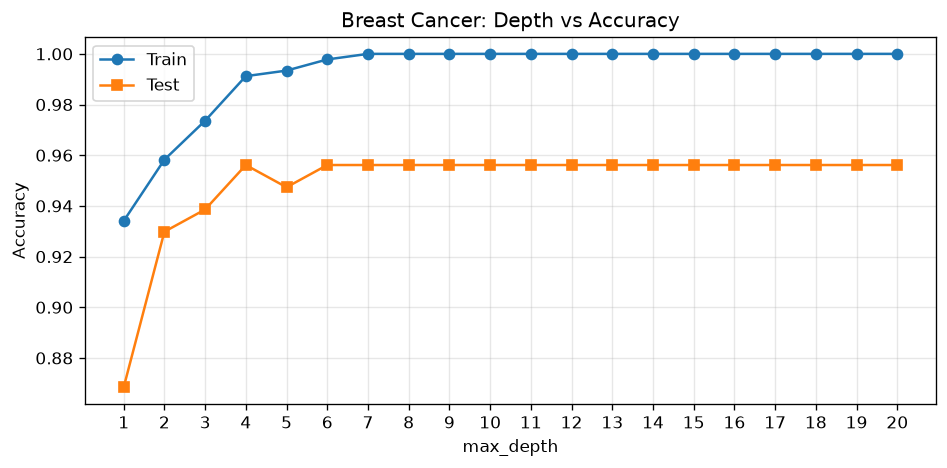

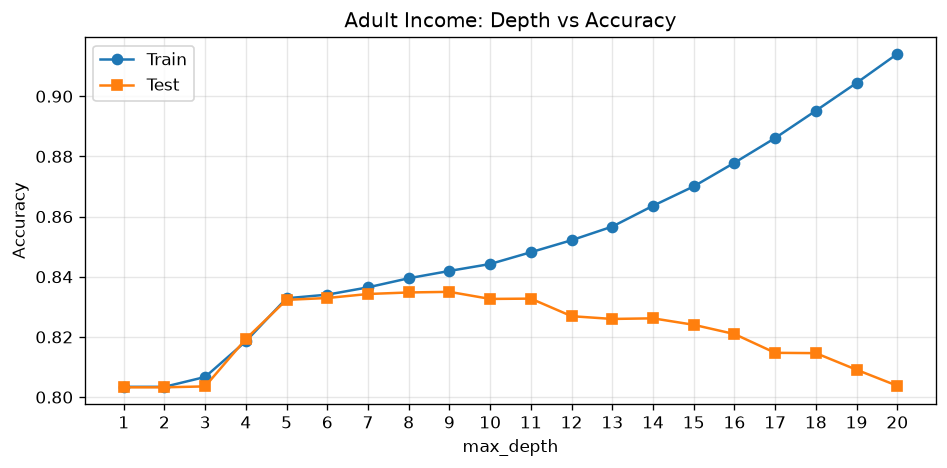

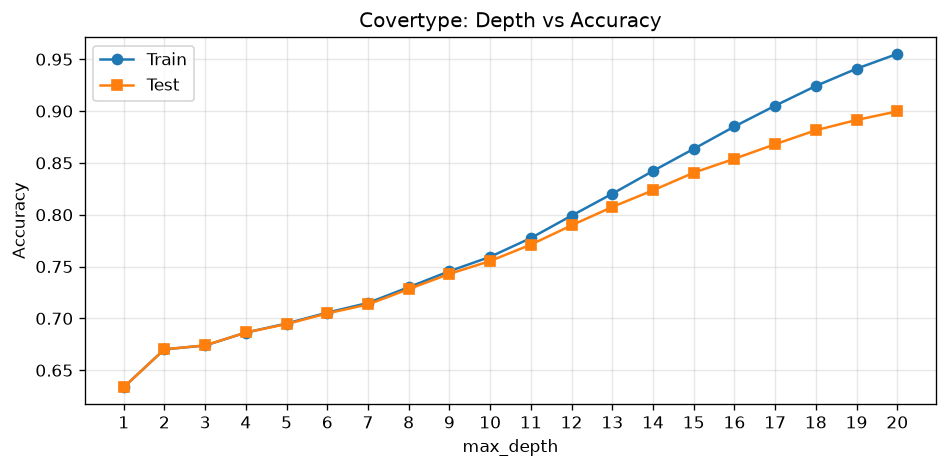

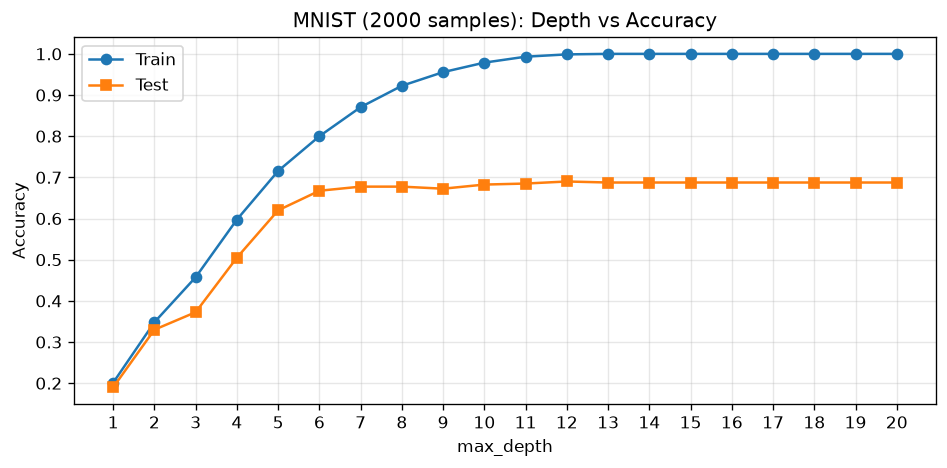

In [9]:
# MNIST üçün 2000 sample seç
rng = np.random.RandomState(RANDOM_STATE)

idx = rng.choice(len(M), 2000, replace=False)

M_small = M[idx]
n_small = n[idx]

# MNIST train/test split
M_train, M_test, n_train, n_test = train_test_split(
    M_small,
    n_small,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Standardization
M_train_s, M_test_s = standardize(M_train, M_test)


datasets = [
    ("Breast Cancer", X_train_s, X_test_s, y_train, y_test),
    ("Adult Income", Z_train_s, Z_test_s, t_train, t_test),
    ("Covertype", A_train_s, A_test_s, b_train, b_test),
    ("MNIST (2000 samples)", M_train_s, M_test_s, n_train, n_test),
]

depths = range(1, 21)

for name, Xtr, Xte, ytr, yte in datasets:

    train_accs = []
    test_accs = []

    for d in depths:
        model = DecisionTree(
            max_depth=d,
            random_state=RANDOM_STATE
        )

        model.fit(Xtr, ytr)

        train_accs.append(
            accuracy_calculation(ytr, model.predict(Xtr))
        )

        test_accs.append(
            accuracy_calculation(yte, model.predict(Xte))
        )

    plt.figure(figsize=(8,4))
    plt.plot(depths, train_accs, "o-", label="Train")
    plt.plot(depths, test_accs, "s-", label="Test")

    plt.xlabel("max_depth")
    plt.ylabel("Accuracy")
    plt.title(f"{name}: Depth vs Accuracy")
    plt.xticks(depths)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
    f"{name.replace(' ', '_')}_depth_accuracy.png",
    dpi=300,
    bbox_inches="tight")
    plt.show()

## 8. Decision Stump — Depth-1 Tree (§2.2.1)

A **decision stump** is a tree with `max_depth=1` — a single split producing
two leaf nodes. This is the weak learner used by AdaBoost.

In [10]:
# Breast Cancer
stump_bc = DecisionStump(random_state=RANDOM_STATE)
stump_bc.fit(X_train_s, y_train)
stump_pred_bc = stump_bc.predict(X_test_s)
print("=== Breast Cancer ===")
print(f"Stump depth: {stump_bc.depth}")
print(f"Stump leaves: {stump_bc.n_leaves}")
print(f"Stump test accuracy: {accuracy_calculation(y_test, stump_pred_bc):.4f}")
print(f"\nStump structure:\n{stump_bc}")

# Adult Income
stump_adult = DecisionStump(random_state=RANDOM_STATE)
stump_adult.fit(Z_train_s, t_train)
stump_pred_adult = stump_adult.predict(Z_test_s)
print("\n=== Adult Income ===")
print(f"Stump depth: {stump_adult.depth}")
print(f"Stump leaves: {stump_adult.n_leaves}")
print(f"Stump test accuracy: {accuracy_calculation(t_test, stump_pred_adult):.4f}")
print(f"\nStump structure:\n{stump_adult}")

# Covertype
stump_cover = DecisionStump(random_state=RANDOM_STATE)
stump_cover.fit(A_train_s, b_train)
stump_pred_cover = stump_cover.predict(A_test_s)
print("\n=== Covertype ===")
print(f"Stump depth: {stump_cover.depth}")
print(f"Stump leaves: {stump_cover.n_leaves}")
print(f"Stump test accuracy: {accuracy_calculation(b_test, stump_pred_cover):.4f}")
print(f"\nStump structure:\n{stump_cover}")

# MNIST
stump_mnist = DecisionStump(random_state=RANDOM_STATE)
stump_mnist.fit(M_train_s, n_train)
stump_pred_mnist = stump_mnist.predict(M_test_s)
print("\n=== MNIST ===")
print(f"Stump depth: {stump_mnist.depth}")
print(f"Stump leaves: {stump_mnist.n_leaves}")
print(f"Stump test accuracy: {accuracy_calculation(n_test, stump_pred_mnist):.4f}")
print(f"\nStump structure:\n{stump_mnist}")

=== Breast Cancer ===
Stump depth: 1
Stump leaves: 2
Stump test accuracy: 0.8684

Stump structure:
DecisionTree(depth=1, n_leaves=2, criterion=gini)
feature_23 <= 0.0213, gini=0.4623, samples=455, value=[165.00, 290.00]
|   leaf: gini=0.1437, samples=308, value=[24.00, 284.00], probs=[0.08, 0.92]
|   leaf: gini=0.0783, samples=147, value=[141.00, 6.00], probs=[0.96, 0.04]


=== Adult Income ===
Stump depth: 1
Stump leaves: 2
Stump test accuracy: 0.8033

Stump structure:
DecisionTree(depth=1, n_leaves=2, criterion=gini)
feature_3 <= 0.5321, gini=0.3639, samples=39073, value=[29729.00, 9344.00]
|   leaf: gini=0.3246, samples=37226, value=[29637.00, 7589.00], probs=[0.80, 0.20]
|   leaf: gini=0.0947, samples=1847, value=[92.00, 1755.00], probs=[0.05, 0.95]


=== Covertype ===
Stump depth: 1
Stump leaves: 2
Stump test accuracy: 0.6335

Stump structure:
DecisionTree(depth=1, n_leaves=2, criterion=gini)
feature_0 <= 0.3046, gini=0.6231, samples=464809, value=[169150.00, 226862.00, 28645.00, 